# Data augmentation with ASL dataset

This notebook implements a Convolutional Neural Network (CNN) for recognizing American Sign Language (ASL) gestures. We will use data augmentation techniques to improve the performance of our model on the ASL dataset.

For more information on the ASL alphabet, you can refer to this site: https://www.asl.gs/

In [1]:
import random

import torch.nn as nn
import pandas as pd
import torch
import torchvision.transforms.v2 as transforms
import torchvision.transforms.functional as F
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.cuda.is_available()

True

In [3]:
data_base_path = "./asl_data/"


### Load data

The data for the ASL dataset is stored in CSV files. It is already split into training, validation, and test sets. Each row in the CSV files contains pixel values for a 28x28 image (flattened into a single row) and a label indicating the ASL gesture.

The labels are integers from 0 to 23, corresponding to the letters A-Z (J and Z are excluded because they require movement).

The images are grayscale, so each pixel value ranges from 0 to 255.

In [4]:
train_df = pd.read_csv(data_base_path + "train.csv")
val_df = pd.read_csv(data_base_path + "val.csv")
test_df = pd.read_csv(data_base_path + "test.csv")

In [5]:
def label_to_letter(lbl):
    letter_code = ord('A') + int(lbl)
    return chr(letter_code) if letter_code < ord('J') else chr(letter_code + 1)

def show(img, lbl):
    i = img.reshape(28,28)
    plt.figure(figsize=(5,5))
    plt.title(label_to_letter(lbl), fontdict={'fontsize': 30})
    plt.axis('off')
    plt.imshow(i, cmap='gray')

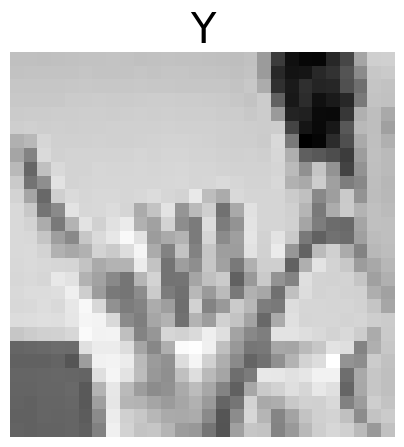

In [6]:
rnd_idx = random.choice(train_df.index)
image = train_df.iloc[rnd_idx].drop('label').values
label = train_df.iloc[rnd_idx]['label']
show(image, label)

## Preparing dataset

Let's start by creating the custom Dataset class for our ASL data. This class will take a DataFrame as input and will return the image and label for each sample. We will also normalize the pixel values to be between 0 and 1. The images will be reshaped as a 28x28 tensor with a single channel (grayscale).

In [7]:
IMG_HEIGHT = 28
IMG_WIDTH = 28
IMG_CHANNELS = 1

class AslDataset(Dataset):
    def __init__(self, base_df):
        x_df = base_df.copy()
        y_df = x_df.pop('label')
        x_df = x_df.values / 255
        x_df = x_df.reshape(-1, IMG_CHANNELS, IMG_WIDTH, IMG_HEIGHT)
        self.xs = torch.tensor(x_df).float().to(device)
        self.ys = torch.tensor(y_df).long().to(device)

    def __getitem__(self, idx):
        x = self.xs[idx]
        y = self.ys[idx]
        return x, y

    def __len__(self):
        return len(self.xs)

In [8]:
train_data = AslDataset(train_df)
val_data = AslDataset(val_df)
test_data = AslDataset(test_df)

In [9]:
batch_size = 32

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=True)

## Training functions

Now we can define our training functions. Since we will use accuracy to evaluate our model, we will create a function to calculate accuracy as well. 

In [10]:
def get_batch_accuracy(output, y, N):
    pred = output.argmax(dim=1, keepdim=True)
    correct = pred.eq(y.view_as(pred)).sum().item()
    return correct / N

Our train function performs the full training loop. For each epoch, it computes the training loss and accuracy, and then evaluates the model on the validation set. It returns the history of training and validation losses and accuracies for plotting later.

In [11]:
def train(_model, _train_loader, _val_loader, _criterion, _optimizer, _num_epochs):
    res = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': [],
    }
    iterator = tqdm(range(epochs), desc="Training", unit="epoch")

    for _ in iterator:
        _model.train()
        train_loss = 0.0
        train_acc = 0.0
        for X_batch, y_batch in _train_loader:
            _optimizer.zero_grad()
            outputs = _model(X_batch)
            loss = _criterion(outputs, y_batch)
            loss.backward()
            _optimizer.step()
            train_loss += loss.item() * X_batch.size(0)
            train_acc += get_batch_accuracy(outputs, y_batch, len(_train_loader.dataset))

        epoch_train_loss = train_loss / len(_train_loader.dataset)

        _model.eval()
        val_loss = 0.0
        val_acc = 0.0
        with torch.no_grad():
            for X_val, y_val in _val_loader:
                val_outputs = _model(X_val)
                val_loss += _criterion(val_outputs, y_val).item() * X_val.size(0)
                val_acc += get_batch_accuracy(val_outputs, y_val, len(_val_loader.dataset))

        epoch_val_loss = val_loss / len(_val_loader.dataset)

        iterator.set_postfix(
            train_loss=f"{epoch_train_loss:.4f}",
            train_acc=f"{train_acc:.4f}",
            val_loss=f"{epoch_val_loss:.4f}",
            val_acc=f"{val_acc:.4f}",
        )

        res['train_loss'].append(epoch_train_loss)
        res['train_acc'].append(train_acc)
        res['val_loss'].append(epoch_val_loss)
        res['val_acc'].append(val_acc)

    return res

This test function will evaluate the model on the test set after training is complete. It will calculate the average loss and accuracy across the entire test set.

In [12]:
def test(_model, _test_loader, _loss_function):
    _model.eval()
    test_loss = 0.0
    test_acc = 0.0
    with torch.no_grad():
        for x, y in _test_loader:
            output = _model(x)
            test_loss += _loss_function(output, y).item() * x.size(0)
            test_acc += get_batch_accuracy(output, y, len(_test_loader.dataset))

    return (test_loss / len(_test_loader.dataset)), test_acc

## Training the models

### CNN model

Now let's implement a simple CNN architecture. We will use three convolutional layers followed by max pooling, and then a couple of fully connected layers before the output layer.

To avoid repeating code, we can define a custom class for each convolutional block (conv layer, activation, and pooling) and then use it to build our CNN model.

In [13]:
class ConvolutionalBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout_p):
        super().__init__()
        kernel_size = 3

        self.model = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size, stride=1, padding=1),
            nn.ReLU(),
            nn.Dropout(dropout_p),
            nn.MaxPool2d(2, stride=2)
        )

    def forward(self, x):
        return self.model(x)

In [14]:
model_cnn = nn.Sequential(
    ConvolutionalBlock(IMG_CHANNELS, 25, 0), # 25 x 14 x 14
    ConvolutionalBlock(25, 50, 0.2),  # 50 x 7 x 7
    ConvolutionalBlock(50, 75, 0),  # 75 x 3 x 3

    nn.Flatten(),
    nn.Linear(75 * 3 * 3, 512),
    nn.Dropout(.3),
    nn.ReLU(),

    nn.Linear(512, 24)
)

model_cnn = model_cnn.to(device)

In [15]:
epochs = 20
loss_function = nn.CrossEntropyLoss()
optimizer = Adam(model_cnn.parameters())

cnn_res = train(model_cnn, train_loader, val_loader, loss_function, optimizer, epochs)


Training: 100%|██████████| 20/20 [02:55<00:00,  8.80s/epoch, train_acc=0.9962, train_loss=0.0141, val_acc=0.9635, val_loss=0.1853]


In [16]:
cnn_test_loss, cnn_test_acc = test(model_cnn, test_loader, loss_function)

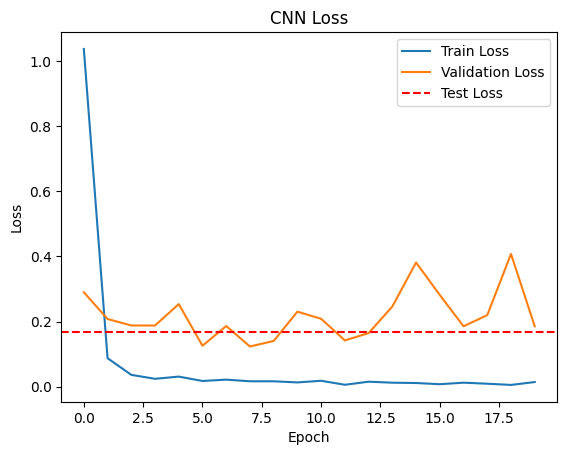

In [17]:
plt.plot(cnn_res['train_loss'], label='Train Loss')
plt.plot(cnn_res['val_loss'], label='Validation Loss')
plt.axhline(cnn_test_loss, label='Test Loss', linestyle='--', color='r')
plt.title('CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

## Data Augmentation

Data augmentation is a technique used to artificially increase the size of a training dataset by creating modified versions of the existing data. This can help improve the generalization of a model and reduce overfitting, especially when the original dataset is small.

The increase in size gives the model more images to learn from while training. The increase in variance helps the model ignore unimportant features and select only the features that are truly important in classification, allowing it to generalize better.

### Random resized crop

This transform will randomly resize the input image based on `scale`, and then crop it to a size we specify. In this case, we will crop it to the original image dimensions. To do this, TorchVision needs to know the aspect ratio of the image it is scaling. Since our height is the same as our width, our aspect `ratio` is 1:1.

In [18]:
trans = transforms.Compose([
    transforms.RandomResizedCrop((IMG_WIDTH, IMG_HEIGHT), scale=(.7, 1), ratio=(1, 1)),
])

In [19]:
def compare_images(_img, t):
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(F.to_pil_image(_img), cmap='gray')
    axes[0].set_title("Original Image")
    axes[0].axis('off')

    img_transformed = t(_img).cpu()
    axes[1].imshow(F.to_pil_image(img_transformed), cmap='gray')
    axes[1].set_title("Transformed Image")
    axes[1].axis('off')
    plt.show()

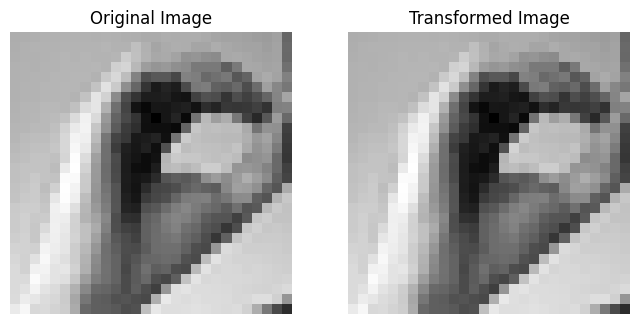

In [20]:
random_idx = random.randint(0, len(train_data) - 1)
img, _ = train_data[random_idx]
compare_images(img.cpu(), trans)

### Random horizontal flip

We can also randomly flip our images [Horizontally](https://pytorch.org/vision/0.9/transforms.html#torchvision.transforms.RandomHorizontalFlip) or [Vertically](https://pytorch.org/vision/0.9/transforms.html#torchvision.transforms.RandomVerticalFlip). However, for these images, we will only flip them horizontally.

American Sign Language can be done with either the left or right hand being dominant. However, it is unlikely to see sign language from upside down. This kind of domain-specific reasoning can help make good decisions for your own deep learning applications.

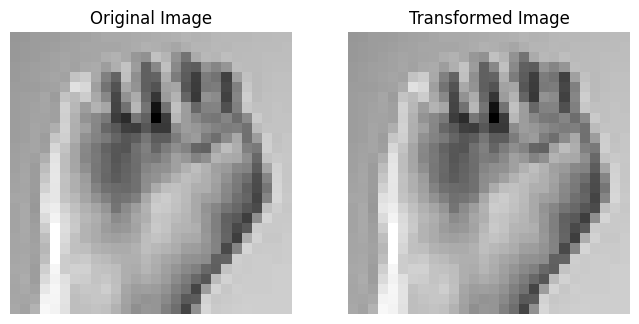

In [21]:
trans = transforms.Compose([
    transforms.RandomHorizontalFlip()
])

random_idx = random.randint(0, len(train_data) - 1)
img, _ = train_data[random_idx]
compare_images(img.cpu(), trans)

### Random rotation

We can also randomly rotate the image to add more variability. Just like with with other augmentation techniques, it's easy to accidentally go too far. With ASL, if we rotate too much, our `D`s might look like `G`s and visa versa. Because of this, let's limit it to `30` degrees.

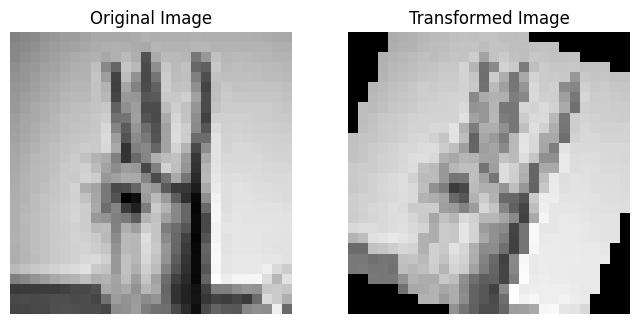

In [22]:
trans = transforms.Compose([
    transforms.RandomRotation(30)
])

random_idx = random.randint(0, len(train_data) - 1)
img, _ = train_data[random_idx]
compare_images(img.cpu(), trans)

### Color jitter

The `ColorJitter` transform has 4 arguments:, brightness, contrast, saturation and hue


The latter 2 apply to color images, so we will only use the first 2 for now.

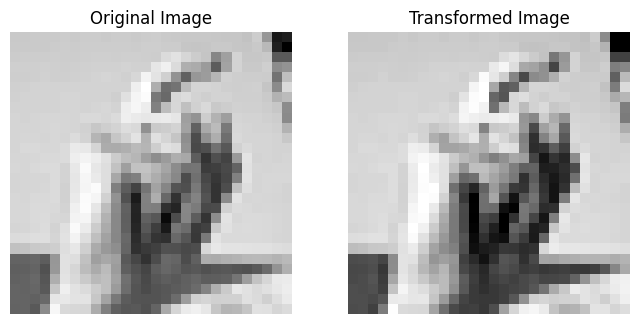

In [23]:
brightness = .2  # Change to be from 0 to 1
contrast = .5  # Change to be from 0 to 1

trans = transforms.Compose([
    transforms.ColorJitter(brightness=brightness, contrast=contrast)
])

random_idx = random.randint(0, len(train_data) - 1)
img, _ = train_data[random_idx]
compare_images(img.cpu(), trans)

## Training with augmentation

Data augmentation occurs during the training loop, where the defined transformations are applied to the training images. We will create a new training function that includes an extra argument with the transformations, and applies them to each batch of training data before feeding it into the model.

In [24]:
def train_aug(_model, _train_loader, _val_loader, _criterion, _optimizer, _num_epochs, _transforms=None):
    res = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': [],
    }
    iterator = tqdm(range(epochs), desc="Training", unit="epoch")

    for _ in iterator:
        _model.train()
        train_loss = 0.0
        train_acc = 0.0
        for X_batch, y_batch in _train_loader:
            _optimizer.zero_grad()
            _x = X_batch
            if _transforms is not None:
                _x = _transforms(_x)
            outputs = _model(_x)
            loss = _criterion(outputs, y_batch)
            loss.backward()
            _optimizer.step()
            train_loss += loss.item() * X_batch.size(0)
            train_acc += get_batch_accuracy(outputs, y_batch, len(_train_loader.dataset))

        epoch_train_loss = train_loss / len(_train_loader.dataset)

        _model.eval()
        val_loss = 0.0
        val_acc = 0.0
        with torch.no_grad():
            for X_val, y_val in _val_loader:
                val_outputs = _model(X_val)
                val_loss += _criterion(val_outputs, y_val).item() * X_val.size(0)
                val_acc += get_batch_accuracy(val_outputs, y_val, len(_val_loader.dataset))

        epoch_val_loss = val_loss / len(_val_loader.dataset)

        iterator.set_postfix(
            train_loss=f"{epoch_train_loss:.4f}",
            train_acc=f"{train_acc:.4f}",
            val_loss=f"{epoch_val_loss:.4f}",
            val_acc=f"{val_acc:.4f}",
        )

        res['train_loss'].append(epoch_train_loss)
        res['train_acc'].append(train_acc)
        res['val_loss'].append(epoch_val_loss)
        res['val_acc'].append(val_acc)

    return res

Let's also define our transformations in a single variable so we can easily pass it to our training function.

In [25]:
random_transforms = transforms.Compose([
    transforms.RandomRotation(15),
    transforms.RandomResizedCrop((IMG_WIDTH, IMG_HEIGHT), scale=(.9, 1), ratio=(1, 1)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=.2, contrast=.5)
])

We can also visualize the transformations to see how they are changing the images.

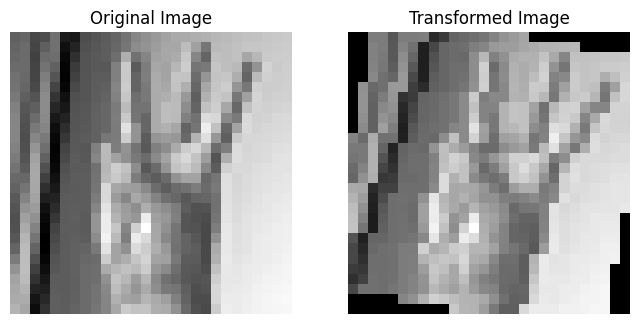

In [26]:
random_idx = random.randint(0, len(train_data) - 1)
img, _ = train_data[random_idx]
compare_images(img.cpu(), random_transforms)

Now we can train the CNN model again, but this time with the defined augmentations applied to the training data.

Note that the augmentation only applies during training, so the test method remains unchanged. Also, this transformation pipeline is inherent to the training loop, so it should not be included in the Dataset or the model itself, as it is only relevant during training.

In [27]:
model_cnn_aug = nn.Sequential(
    ConvolutionalBlock(IMG_CHANNELS, 25, 0), # 25 x 14 x 14
    ConvolutionalBlock(25, 50, 0.2),  # 50 x 7 x 7
    ConvolutionalBlock(50, 75, 0),  # 75 x 3 x 3

    nn.Flatten(),
    nn.Linear(75 * 3 * 3, 512),
    nn.Dropout(.3),
    nn.ReLU(),

    nn.Linear(512, 24)
)

model_cnn_aug = model_cnn_aug.to(device)

In [28]:
epochs = 20
loss_function = nn.CrossEntropyLoss()
optimizer = Adam(model_cnn_aug.parameters())

cnn_aug_res = train_aug(model_cnn_aug, train_loader, val_loader, loss_function, optimizer, epochs, random_transforms)

Training: 100%|██████████| 20/20 [03:57<00:00, 11.85s/epoch, train_acc=0.9809, train_loss=0.0590, val_acc=0.9796, val_loss=0.0966]


In [29]:
cnn_aug_test_loss, cnn_aug_test_acc = test(model_cnn_aug, test_loader, loss_function)

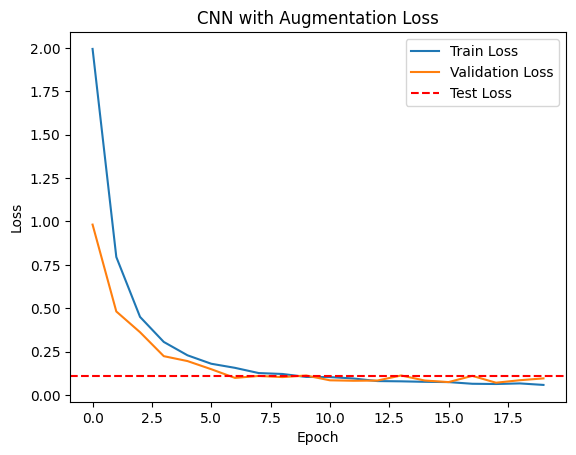

In [30]:
plt.plot(cnn_aug_res['train_loss'], label='Train Loss')
plt.plot(cnn_aug_res['val_loss'], label='Validation Loss')
plt.axhline(cnn_aug_test_loss, label='Test Loss', linestyle='--', color='r')
plt.legend()
plt.title('CNN with Augmentation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

## Reflection section

**Contestare en espanol**

### What impact did data augmentation had on the model performance?

DEFINITIVAMENTE, hubo una mejora muy grande al haver entrenado nuestro modelo con data augmentation, y de hecho se puede ver en la grafica del Loss. Para el set sin data augmentation, nosotros tuvimos Overfitting porque la curva de loss para train estuvo mas abajo que la de validation y el run en test quedo mas arriba que todas, osea basicamente generalizo mal en datos nunca antes visto porque tuvimos el peor performance, peor que train y validation. 


Pero al hacer data augmentation y tener mas imagenes diversas, tuvimos un performance muy superior al otro modelo entrenado en datos sin data augmentation. Esto se puede visualizar de manera super sencilla en los plots de las curvas de perdida, ya que ahora en este modelo entrenado con data augmentation no presentamos overfitting, mientras que en el otro si, el performance para el validation loss fue muy bueno no como en el otro donde solo el train loss fue bueno y el validation loss malo. Y la diferencia mayor de todas donde podemos realmente darnos cuenta en la superioridad es el test loss. La iteracion que hicimos sobre el test set con este modelo nos fue casi igual de bien que en el train set y validation set, significando que este modelo SI generaliza bien y se comporto excelente con datos nunca antes vistos. Para este problema y dataset especificos, hacer data augmentation tuvo un mejor desempeno

### Re-run training with a smaller subset of train data (both with augmentation and without it)

Okay para esta tarea nos piden volver a entrenar la red neuronal pero con un subset mas chiquito sin data augmentation y uno mas chiquito con data augmentation 

Primero voy a visualizar la cantidad de imagenes, de esta manera puedo saber que tanto puedo acotar el dataframe

In [31]:
train_df.shape

(27455, 785)

In [32]:
val_df.shape

(3586, 785)

In [33]:
test_df.shape

(3586, 785)

In [34]:
train_datasmall = AslDataset(train_df[:10000])
val_datasmall = AslDataset(val_df[:2500])
test_datasmall = AslDataset(test_df[:2500])

batch_size = 32

train_loadersmall = DataLoader(train_datasmall, batch_size=batch_size, shuffle=True)
val_loadersmall = DataLoader(val_datasmall, batch_size=batch_size, shuffle=True)
test_loadersmall = DataLoader(test_datasmall, batch_size=batch_size, shuffle=True)

Okay ahora si teniendo el subset mas pequeno simplemente tengo que llamar la funcion de entrenamiento con Aug y sin Aug pero con este dataloader (Cambie el nombre de la funcion de entrenamiento con augmentation para poder identificarlos ya que uno acepta el parametro transformaciones y la otra no)

**Recordemos que asi nos fue en el primer test con dataloader normal pero sin data augmentation**

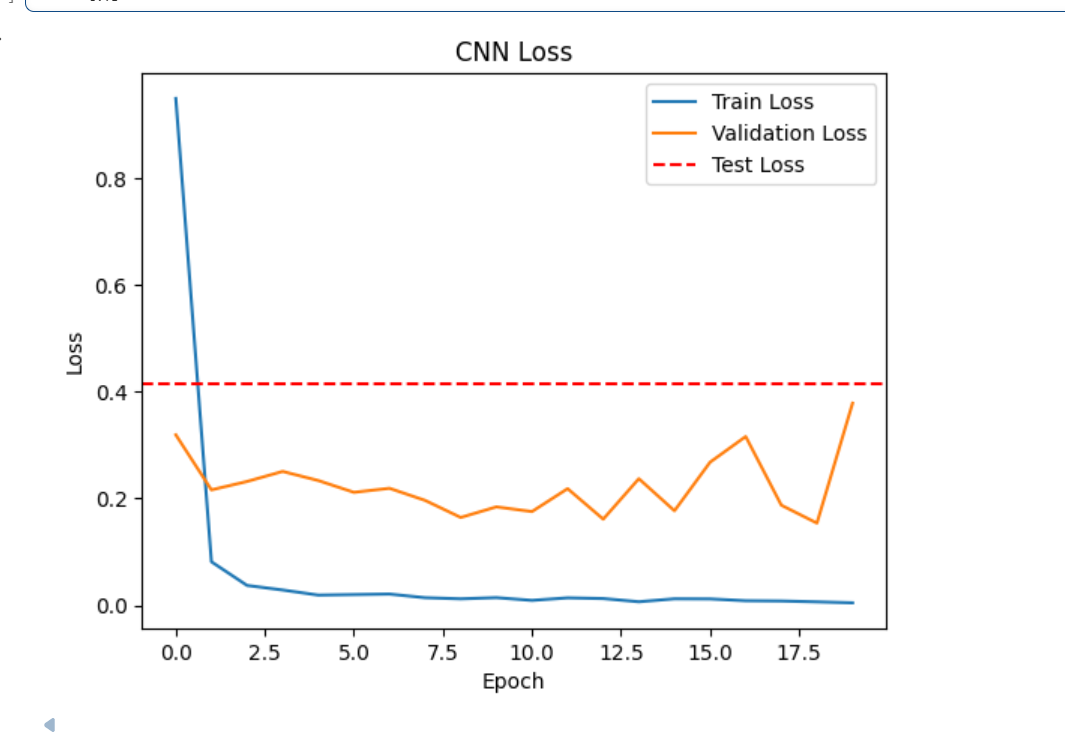

**SIN AUGMENTATION**

Tengo que volver a definir la arquitectura de la red neuronal porque si empiezo a entrenar asi con el objeto anterior no seria una comparativa real porque ya trae los pesos entrenados de el ultimo entrenamiento (Lo digo porque me paso y pense que me habia ido mucho mejor que con el subset normal)

In [35]:
model_cnn_SMALL = nn.Sequential(
    ConvolutionalBlock(IMG_CHANNELS, 25, 0), # 25 x 14 x 14
    ConvolutionalBlock(25, 50, 0.2),  # 50 x 7 x 7
    ConvolutionalBlock(50, 75, 0),  # 75 x 3 x 3

    nn.Flatten(),
    nn.Linear(75 * 3 * 3, 512),
    nn.Dropout(.3),
    nn.ReLU(),

    nn.Linear(512, 24)
)

model_cnn_SMALL = model_cnn_SMALL.to(device)

In [36]:
epochs = 20
loss_function = nn.CrossEntropyLoss()
optimizer = Adam(model_cnn_SMALL.parameters())

cnn_res = train(model_cnn_SMALL, train_loadersmall, val_loadersmall, loss_function, optimizer, epochs)


Training: 100%|██████████| 20/20 [00:27<00:00,  1.38s/epoch, train_acc=0.9944, train_loss=0.0147, val_acc=0.9764, val_loss=0.0825]


In [37]:
cnn_test_loss, cnn_test_acc = test(model_cnn_SMALL, test_loadersmall, loss_function)

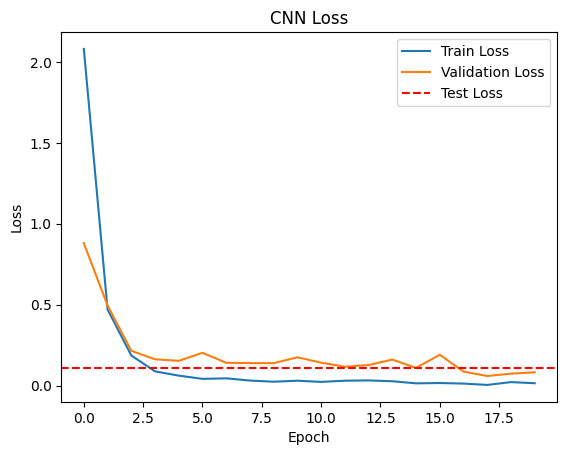

In [38]:
plt.plot(cnn_res['train_loss'], label='Train Loss')
plt.plot(cnn_res['val_loss'], label='Validation Loss')
plt.axhline(cnn_test_loss, label='Test Loss', linestyle='--', color='r')
plt.title('CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

**CON AUGMENTATION**

In [39]:
model_cnn_aug_SMALL = nn.Sequential(
    ConvolutionalBlock(IMG_CHANNELS, 25, 0), # 25 x 14 x 14
    ConvolutionalBlock(25, 50, 0.2),  # 50 x 7 x 7
    ConvolutionalBlock(50, 75, 0),  # 75 x 3 x 3

    nn.Flatten(),
    nn.Linear(75 * 3 * 3, 512),
    nn.Dropout(.3),
    nn.ReLU(),

    nn.Linear(512, 24)
)

model_cnn_aug_SMALL = model_cnn_aug_SMALL.to(device)

In [40]:
epochs = 20
loss_function = nn.CrossEntropyLoss()
optimizer = Adam(model_cnn_aug_SMALL.parameters())

cnn_aug_res = train_aug(model_cnn_aug_SMALL, train_loadersmall, val_loadersmall, loss_function, optimizer, epochs, random_transforms)

Training: 100%|██████████| 20/20 [00:34<00:00,  1.75s/epoch, train_acc=0.9484, train_loss=0.1557, val_acc=0.9300, val_loss=0.1801]


In [41]:
cnn_aug_test_loss, cnn_aug_test_acc = test(model_cnn_aug_SMALL, test_loadersmall, loss_function)

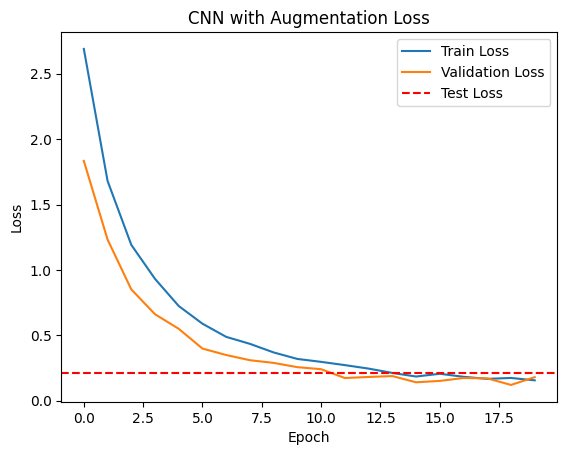

In [42]:
plt.plot(cnn_aug_res['train_loss'], label='Train Loss')
plt.plot(cnn_aug_res['val_loss'], label='Validation Loss')
plt.axhline(cnn_aug_test_loss, label='Test Loss', linestyle='--', color='r')
plt.legend()
plt.title('CNN with Augmentation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

**remarks**

Okay despues de correrlos, nos fue mejor con un subset mas pequeno, pero algo interesante es que nos fue muy similar, con el subset pequeno ya sea con data augmentation o sin data augmentation, pero por muy leve, el subset con data augmentation nos fue un poco peor y la verdad es que si me imagine porque de por si el subset es pequeno y le estamos aplicando data augmentation jajaja, pues no esta viendo las mejores imagenes entonces aunque le va bien le va mejor al que no tuvo data augmentation

### Re-train the model using a different transformation pipeline for augmentation

Refer to the following documentation page: https://docs.pytorch.org/vision/stable/transforms.html

Okay ahorita las transformaciones que tenemos son las siguientes: entonces voy a tratar de agregar mas o quitar transformaciones? para ver como se desenvuelve

In [ ]:
random_transforms = transforms.Compose([
    transforms.RandomRotation(15),
    transforms.RandomResizedCrop((IMG_WIDTH, IMG_HEIGHT), scale=(.9, 1), ratio=(1, 1)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=.2, contrast=.5)
])

Agregamos mas transformaciones jaja nomas para ver si sirve de algo

In [45]:
random_transforms2 = transforms.Compose([
    transforms.RandomRotation(15),
    transforms.RandomResizedCrop((IMG_WIDTH, IMG_HEIGHT), scale=(.9, 1), ratio=(1, 1)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=.2, contrast=.5),
    transforms.RandomCrop(size=(IMG_WIDTH, IMG_HEIGHT), padding=2),
    transforms.CenterCrop(size=(IMG_WIDTH, IMG_HEIGHT)),
    transforms.RandomAffine(degrees=10, translate=(0.05, 0.05)),
    transforms.ElasticTransform(alpha=30.0, sigma=5.0)
])

Train with new transformations

In [46]:
model_cnn_aug2 = nn.Sequential(
    ConvolutionalBlock(IMG_CHANNELS, 25, 0), # 25 x 14 x 14
    ConvolutionalBlock(25, 50, 0.2),  # 50 x 7 x 7
    ConvolutionalBlock(50, 75, 0),  # 75 x 3 x 3

    nn.Flatten(),
    nn.Linear(75 * 3 * 3, 512),
    nn.Dropout(.3),
    nn.ReLU(),

    nn.Linear(512, 24)
)

model_cnn_aug2 = model_cnn_aug2.to(device)

In [47]:
epochs = 20
loss_function = nn.CrossEntropyLoss()
optimizer = Adam(model_cnn_aug2.parameters())

cnn_aug_res = train_aug(model_cnn_aug2, train_loader, val_loader, loss_function, optimizer, epochs, random_transforms2)

Training: 100%|██████████| 20/20 [05:30<00:00, 16.51s/epoch, train_acc=0.9069, train_loss=0.2821, val_acc=0.9632, val_loss=0.1141]


In [48]:
cnn_aug_test_loss, cnn_aug_test_acc = test(model_cnn_aug2, test_loader, loss_function)

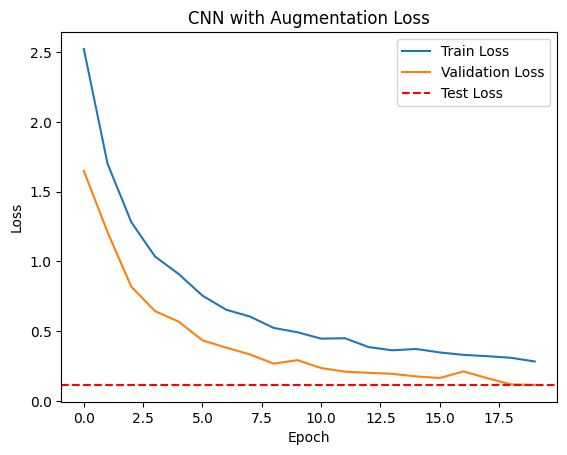

In [49]:
plt.plot(cnn_aug_res['train_loss'], label='Train Loss')
plt.plot(cnn_aug_res['val_loss'], label='Validation Loss')
plt.axhline(cnn_aug_test_loss, label='Test Loss', linestyle='--', color='r')
plt.legend()
plt.title('CNN with Augmentation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

Antes de dar mis remarks sobre otro transformation pipeline lo que si puedo confirmar es que tardo mucho MAS en entrenar jaja con mas transformaciones, 6 minutos casi, comparado con 27 segundos en el smaller subset sin augmentation

Okay que es lo interesante de este test? ya sabemos que tardo mucho mas tiempo en entrenar por la naturaleza que estamos aplicando muchas mas transformaciones y todas esas consumen poder computacional por imagen por batch size, por epoch jajaj entonces ya se agrega mas computacion

Agregar tantas transformaciones hizo que fuera de los mejores performances, pero eso no es lo mas interesante si no las curvas jajaj, literalmente la curva de loss de train es la que esta mas arriba lo cual es super raro, seria como algo mejor a overfitting lo que nos paso jaja que las curvas de test y validation nos fue mejor que la de train

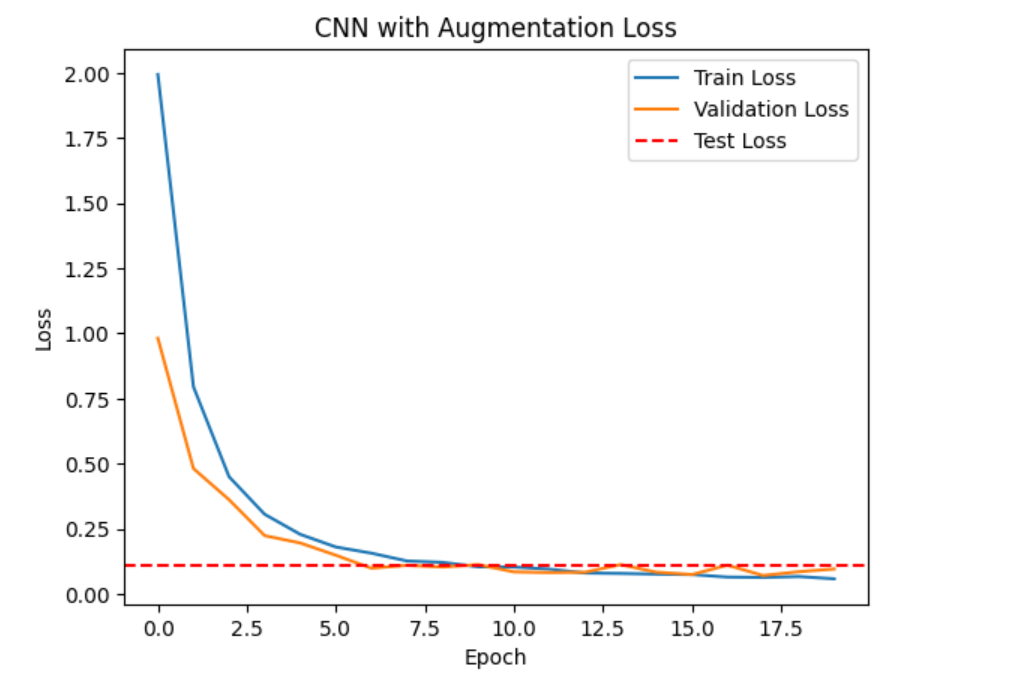

Para recordar, asi nos fue con augmentation en el set grande pero con pocas transformaciones no tantas, entonces esta es la fair comparacion, y podemos deducir que nos fue muy similar en test set. lo que cambio fue validation y train loss curves, aunque pareciera que nos fue mejor en el de arriba con muchas transformaciones porque estan mas arriba las curvas, la realidad es que nos fue mejor en el run con menos transformaciones que es esta ultima grafica, porque tarda menos en aprender y bajar su curva del loss. Lo que si podemos rescatar del run con muchas transformaciones fue que aunque train y validation nos fue peor test fue donde nos fue mejor

### Write down your final remarks

Aprendi varias cosas con esta actividad, ya tenia una idea de que es lo que hace data augmentation y ya lo habia implementado, pero no habia hecho experimentos tan especificos sobre esto. Lo primero que vi interesante fue el experimento con muchas transformaciones, el cual resulto en un train loss muy alto, pero en un validation loss y test loss bajo y de hecho de los mejores runs para el test loss. Esto lo veo muy posible porque si estas entrenando la red neuronal con imagenes dificiles, muy transformadas y no limpias y despues en validation o test le pones imagenes super limpias puede que hasta mejore el performance que empeorar

Tambien aprendi que con augmentation le fue mejor a la red neuronal en este caso, y con el small subset. Pero su peor run fue asi seco sin small subset ni augmentation, entonces definitivamente si me esta llendo mal en mi red neuronal de ahora en adelante considerare hacer transformaciones a las imagenes o reducir subsets, etc. Igual y no especificamente esto pero si tratar de jugar con algo antes de seguir entrenando o darme por vencido jkaja